In [12]:
# Environment and Import
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys 
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))
from src.yieldcurve import load_rba_yield_curve, validate_yield_data, YieldCurve
F17_PATH = os.path.join(os.path.dirname(os.getcwd()), "data", "RBA_Government_Bond_Yields.csv")
print("Imports OK")
print(sys.version)


Imports OK
3.14.3 (v3.14.3:323c59a5e34, Feb  3 2026, 11:41:37) [Clang 16.0.0 (clang-1600.0.26.6)]


## Yield Curve Data Source

Risk-free rates are sourced from the **RBA F17 Zero-Coupon Interest Rates – Analytical Series** (cached CSV), which provides Australian Commonwealth Government zero-coupon yields across a dense grid of maturities.

We use the most recent complete daily snapshot, spanning maturities from 0 to 10 years in quarter-year steps (41 pillars). Using the zero-coupon series directly is well suited to derivatives pricing: option payoffs occur at specific maturities, and zero rates give the correct horizon-consistent discount factor for each without any bootstrapping step.

Yields are quoted as percentages and converted to decimals on load. The `YieldCurve` class then linearly interpolates between the observed pillars to return a zero rate for any maturity, and converts that rate into a continuous-compounding discount factor for use by the pricing engine.

In [13]:
maturities, zero_rates, snap_date = load_rba_yield_curve(F17_PATH)
validate_yield_data(maturities, zero_rates)
yc = YieldCurve(maturities, zero_rates)

print(f"Snapshot date : {snap_date.date()}")
print(f"Pillars       : {len(maturities)}  ({maturities[0]:.2f}yr – {maturities[-1]:.2f}yr)")
print(f"Rate range    : {zero_rates.min():.4%} – {zero_rates.max():.4%}")
print(repr(yc))


Snapshot date : 2026-03-31
Pillars       : 41  (0.00yr – 10.00yr)
Rate range    : 4.1000% – 4.9500%


In [14]:
# Create an instance of the YieldCurve class
curve = YieldCurve(
    maturities = maturities,
    zero_rates = zero_rates,
    compounding = "annual"
    )

In [15]:
# Sanity checks
test_maturities = [0.75, 3.0, 7.0]
for T in test_maturities:
    z = curve.get_zero_rate(T)
    d = curve.get_discount_factor(T)
    print(f"T = {T:.2f} years | Zero rate = {z:.2%} | Discount factor = {d:.2%}")

T = 0.75 years | Zero rate = 4.43% | Discount factor = 96.80%
T = 3.00 years | Zero rate = 4.59% | Discount factor = 87.40%
T = 7.00 years | Zero rate = 4.77% | Discount factor = 72.17%


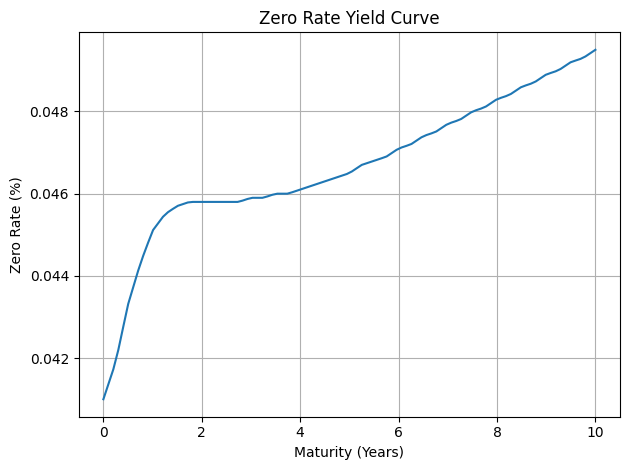

In [16]:
# Plot
curve.plot(max_maturity = 10)